<a href="https://colab.research.google.com/github/inaraaalves/mini-projeto-1-dsa/blob/main/260312_full_MINI_PROJETO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota inicial:

Meu projeto foi baseado no MINI PROJETO 1 do Curso Fundamentos de Linguagem Python da DATA SCIENCE ACADEMY.

.
Capítulo 06
Repetição, Tomada de Decisão e Modularização - Loops, Condicionais e Funções


# Análise de Vendas para Loja de E-commerce com Pandas, Numpy e Matplotlib

O Mini-Projeto1 é um trabalho completo de análise de dados em Python.

Usando bibliotecas, como Pandas, NumPy e Matplotlib, o projeto busca consolidar, limpar e explorar os registros de vendas, revelando padrões ocultos e gerando visualizações claras. O resultado esperado é fornecer insights acionáveis que permitam otimizar oportfólio de produtos, direcionar campanhas de marketing, antecipar tendências sazonais e guiar decisões de expansão regional, estabelecendo uma cultura de tomada de decisão orientada por dados.

# Definição do Problema de Negócio

## 1. O Problema de Negócio

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado  bruto,  é  como  um  baú  de  tesouro  trancado:  sabemos  que  há  valor  ali,  mas  não conseguimos acessá-lo.

Atualmente,   muitas   de   nossas   decisões   estratégicas   são   baseadas   em   intuição   e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão  de  Estoque  Ineficiente:  Não  temos  clareza  sobre  quais  produtos  são  nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências

## 2. Objetivos do Projeto

Este  projeto  de  análise  de  dados  visa  transformar  nossos  dados  brutos  de  vendas  em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.

- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.
- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.
- Para  onde  expandir?  Mapear  a  distribuição  geográfica  de  nossas  vendas  para descobrir nossos mercados mais fortes.



## 2. Importação das Bibliotecas

In [ ]:
# Manipulação de dados em tabelas
import pandas as pd

# Para operações matemáticas e arrays
import numpy as np

# Para geração de gráficos
import matplotlib.pyplot as plt

# Importa a função FuncFormatter para eixos de gráficos
from matplotlib.ticker import FuncFormatter

# Visualização estatística de dados
import seaborn as sns

# Classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

# Comando que permite exibir gráficos diretamente no notebook
%matplotlib inline



## 3. Carregar e Explorar os Dados

In [ ]:
# Carrega o csv com os dados de Vendas Fictícias
df_vendas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA SCIENCE ACADEMY/Mini Projeto 1/petalas_dados_de_vendas.csv')

In [ ]:
# Visualizar as 5 primeiras linhas do DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2025-01-01 23:00:00,Batom Matte,Maquiagem,85.0,1,160,Manaus,AM
1,1001,2025-01-01 12:00:00,Perfume Elegance,Perfumaria,350.0,6,189,Rio de Janeiro,RJ
2,1002,2025-01-01 00:00:00,Base Lux,Maquiagem,80.0,8,226,Curitiba,PR
3,1003,2025-01-01 16:00:00,Perfume Bloom,Perfumaria,100.0,9,211,Porto Alegre,RS
4,1004,2025-01-01 10:00:00,Perfume Elegance,Perfumaria,350.0,3,189,Manaus,AM


In [ ]:
# Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
1495,2495,2025-10-27 18:00:00,Base Lux,Maquiagem,80.00,9,233,São Paulo,SP
1496,2496,2025-10-27 20:00:00,Condicionador Luxo,Banho,58.60,7,147,Manaus,AM
1497,2497,2025-10-27 07:00:00,Batom Matte,Maquiagem,85.00,2,124,São Paulo,SP
1498,2498,2025-10-27 10:00:00,Condicionador Luxo,Banho,59.07,2,152,São Luís,MA
1499,2499,2025-10-27 18:00:00,Condicionador Luxo,Banho,56.11,5,107,Fortaleza,CE


In [ ]:
# Shape, Verificamos a quantidades de linhas e de colunas na tabela
df_vendas.shape

(1500, 9)

In [ ]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Pedido       1500 non-null   int64  
 1   Data_Pedido     1500 non-null   object 
 2   Nome_Produto    1500 non-null   object 
 3   Categoria       1500 non-null   object 
 4   Preco_Unitario  1500 non-null   float64
 5   Quantidade      1500 non-null   int64  
 6   ID_Cliente      1500 non-null   int64  
 7   Cidade          1500 non-null   object 
 8   Estado          1500 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 105.6+ KB


In [ ]:
# Resumo estatístico (somente dados numéricos)
df_vendas.describe()

,ID_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,1749.500000,112.538307,5.033333,172.390000
std,433.157015,92.309459,2.613958,43.465021
min,1000.000000,45.020000,1.000000,100.000000
25%,1374.750000,50.000000,3.000000,134.000000
50%,1749.500000,80.000000,5.000000,171.000000
75%,2124.250000,100.000000,7.000000,210.250000
max,2499.000000,350.000000,9.000000,249.000000


## 4. Limpeza, Pré-Processamento e Engenharia de Atributos

In [ ]:
# Converte 'Data_Pedido' no tipo datetime, caso não esteja
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [ ]:
# Cria a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [ ]:
# Lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['AM', 'PA'] else 'Normal')

In [ ]:
# Exibe informações gerais atualizadas sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       1500 non-null   int64         
 1   Data_Pedido     1500 non-null   datetime64[ns]
 2   Nome_Produto    1500 non-null   object        
 3   Categoria       1500 non-null   object        
 4   Preco_Unitario  1500 non-null   float64       
 5   Quantidade      1500 non-null   int64         
 6   ID_Cliente      1500 non-null   int64         
 7   Cidade          1500 non-null   object        
 8   Estado          1500 non-null   object        
 9   Faturamento     1500 non-null   float64       
 10  Status_Entrega  1500 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 129.0+ KB


In [ ]:
# Exibe a atualização das 5 primeiras linhas para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2025-01-01 23:00:00,Batom Matte,Maquiagem,85.0,1,160,Manaus,AM,85.0,Rápida
1,1001,2025-01-01 12:00:00,Perfume Elegance,Perfumaria,350.0,6,189,Rio de Janeiro,RJ,2100.0,Normal
2,1002,2025-01-01 00:00:00,Base Lux,Maquiagem,80.0,8,226,Curitiba,PR,640.0,Normal
3,1003,2025-01-01 16:00:00,Perfume Bloom,Perfumaria,100.0,9,211,Porto Alegre,RS,900.0,Normal
4,1004,2025-01-01 10:00:00,Perfume Elegance,Perfumaria,350.0,3,189,Manaus,AM,1050.0,Rápida


## 5. Análise 1 - Top 10 Produtos Mais Vendidos
Quais os top 10 produtos mais vendidos?

In [ ]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [ ]:
# Exibe o resultado dos produtos mais vendidos
top_10_produtos

,Quantidade
Nome_Produto,
Gloss Crystal,1021
Condicionador Luxo,996
Batom Matte,976
Perfume Bloom,970
Perfume Aurora,927
Esfoliante Premium,905
Base Lux,881
Perfume Elegance,874


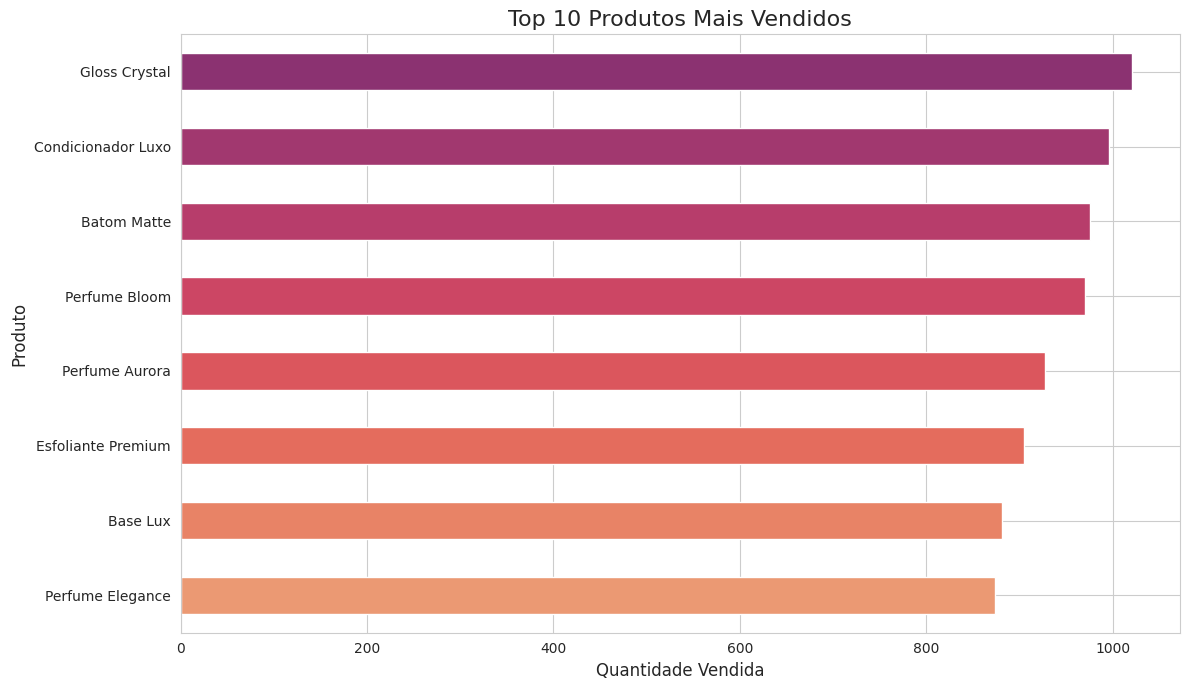

In [ ]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = sns.color_palette("flare", 10))

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

## 8. Análise 2 - Faturamento Mensal

Qual foi o faturamento mensal?

In [ ]:
# Cria uma coluna 'Mes' para o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [ ]:
df_vendas.head() # prévia com a coluna 'mês'

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2025-01-01 23:00:00,Batom Matte,Maquiagem,85.0,1,160,Manaus,AM,85.0,Rápida,2025-01
1,1001,2025-01-01 12:00:00,Perfume Elegance,Perfumaria,350.0,6,189,Rio de Janeiro,RJ,2100.0,Normal,2025-01
2,1002,2025-01-01 00:00:00,Base Lux,Maquiagem,80.0,8,226,Curitiba,PR,640.0,Normal,2025-01
3,1003,2025-01-01 16:00:00,Perfume Bloom,Perfumaria,100.0,9,211,Porto Alegre,RS,900.0,Normal,2025-01
4,1004,2025-01-01 10:00:00,Perfume Elegance,Perfumaria,350.0,3,189,Manaus,AM,1050.0,Rápida,2025-01


In [ ]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [ ]:
faturamento_mensal # prévia do agrupamento

,Faturamento
Mes,
2025-01,94248.22
2025-02,70039.70
2025-03,84510.58
2025-04,88804.95
2025-05,83798.15
2025-06,98145.42
2025-07,87053.30
2025-08,79482.76
2025-09,88290.44


In [ ]:
# Converte o índice para string para a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [ ]:
# Formata para duas casas decimais com R$
faturamento_mensal.map('R$ {:,.2f}'.format)

,Faturamento
Mes,
2025-01,"R$ 94,248.22"
2025-02,"R$ 70,039.70"
2025-03,"R$ 84,510.58"
2025-04,"R$ 88,804.95"
2025-05,"R$ 83,798.15"
2025-06,"R$ 98,145.42"
2025-07,"R$ 87,053.30"
2025-08,"R$ 79,482.76"
2025-09,"R$ 88,290.44"


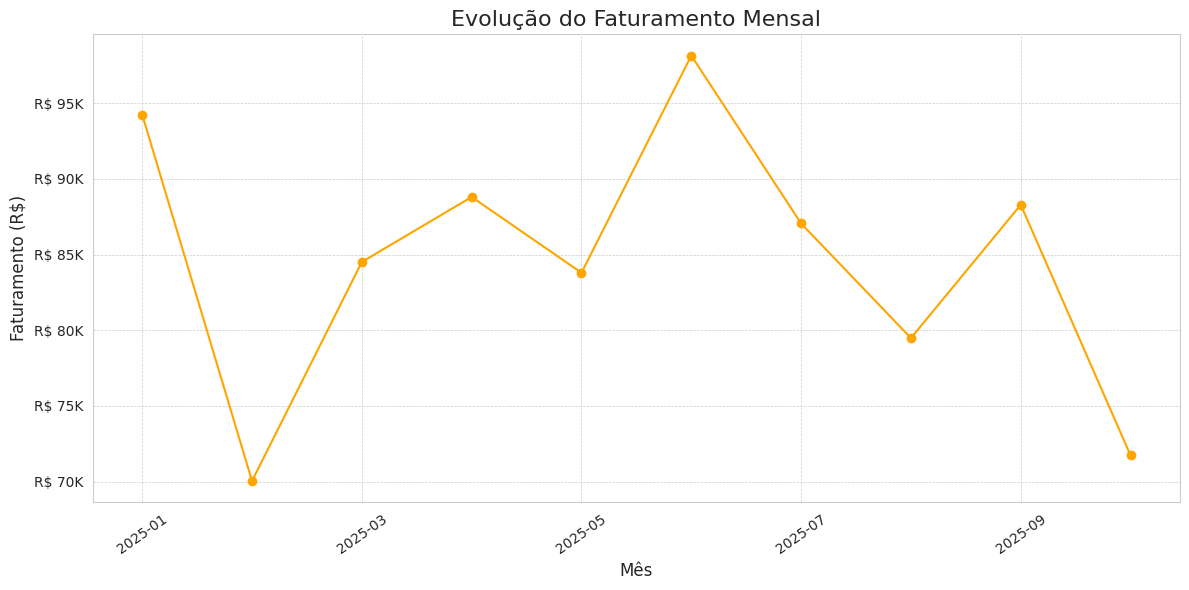

In [ ]:
# PLOTAGEM DO GRÁFICO DE FATURAMENTO MENSAL


# Cria uma figura
fig, ax = plt.subplots(figsize = (12, 6))

# Função para formatar os números
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', ax = ax, color = 'orange')

# Adiciona títulos e labels
plt.title('Evolução do Faturamento Mensal', fontsize = 16)
plt.xlabel('Mês', fontsize = 12)
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotaciona os valores do eixo X
plt.xticks(rotation = 35)

# Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# Ajusta os elementos para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 7. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [ ]:
# Agrupa por estado e soma o faturamento
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [ ]:
# Formata para duas casas decimais com R$
vendas_estado.map('R$ {:,.2f}'.format)

,Faturamento
Estado,
BA,"R$ 100,541.81"
SP,"R$ 95,113.27"
RJ,"R$ 94,190.88"
MG,"R$ 90,698.23"
PA,"R$ 86,118.12"
MA,"R$ 82,334.79"
AM,"R$ 80,664.98"
PR,"R$ 75,602.62"
RS,"R$ 71,072.65"


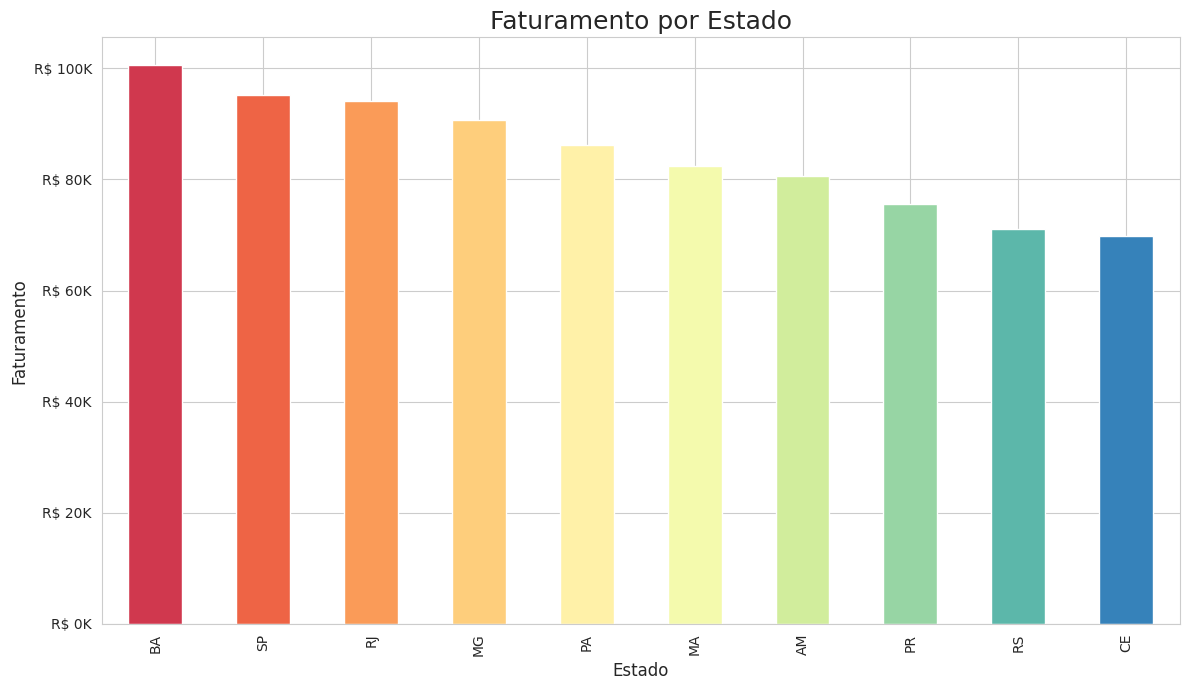

In [ ]:
# PLOTAGEM DO GRÁFICO DE VENDAS POR ESTADO


# Cria uma nova figura
fig,ax = plt.subplots(figsize = (12, 7))

# Função para formatar os números
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados com 'ax'
vendas_estado.plot(kind = 'bar', ax = ax, color = sns.color_palette("Spectral", len(vendas_estado)))

# Adiciona títulos e labels
plt.title('Faturamento por Estado', fontsize = 18)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Faturamento', fontsize = 12)

# Ajusta os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 8. Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [ ]:
# Agrupa por categoria e soma o faturamento
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [ ]:
# Formata para duas casas decimais com R$
faturamento_categoria.map('R$ {:,.2f}'.format)

,Faturamento
Categoria,
Perfumaria,"R$ 541,950.00"
Maquiagem,"R$ 204,490.00"
Banho,"R$ 99,658.23"


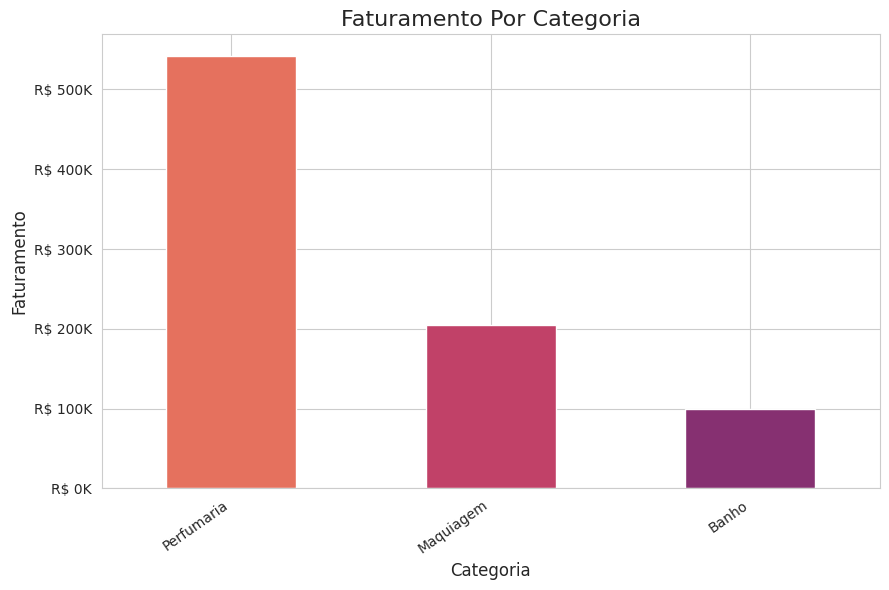

In [ ]:
# PLOTAGEM DO GRÁFICO DE VENDAS POR CATEGORIA


# Ordena os dados
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

# Cria a Figura
fig, ax = plt.subplots(figsize = (9, 6))

# Função para formatar os números
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)


# Plota os dados com 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("flare", len(faturamento_ordenado)))

# Adiciona títulos e labels
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajustes e rotação dos rótulos do eixo X
plt.xticks(rotation = 35, ha = 'right')
plt.tight_layout()

# Exibe o gráfico
plt.show()

# Conclusão:

[o resultado completo pode ser consultado em anexo na pasta de arquivos onde está esse código]

# O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.

Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.


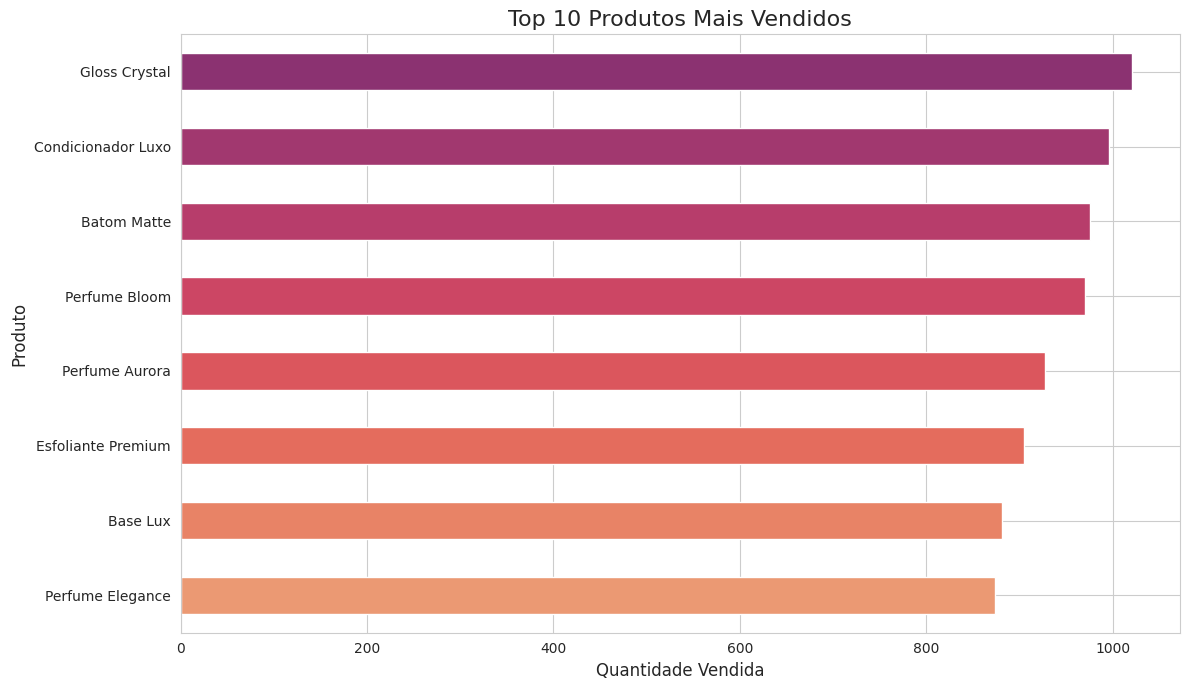

# Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

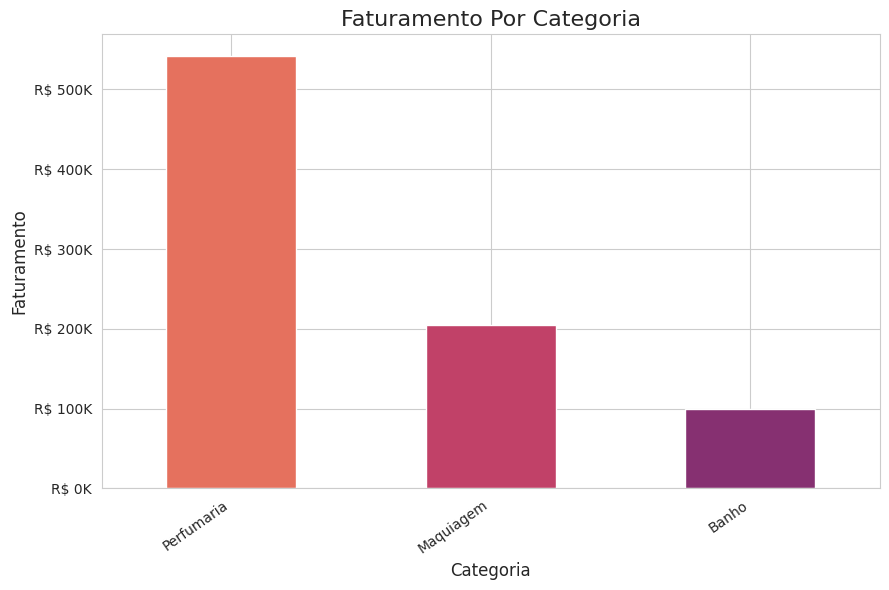

# Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

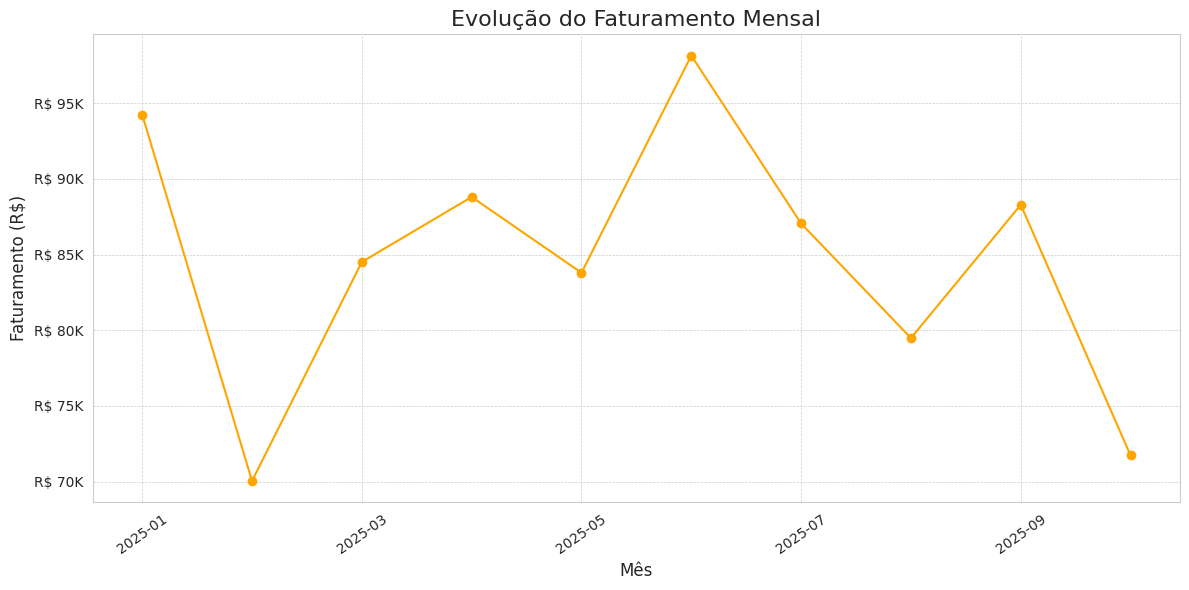

# Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

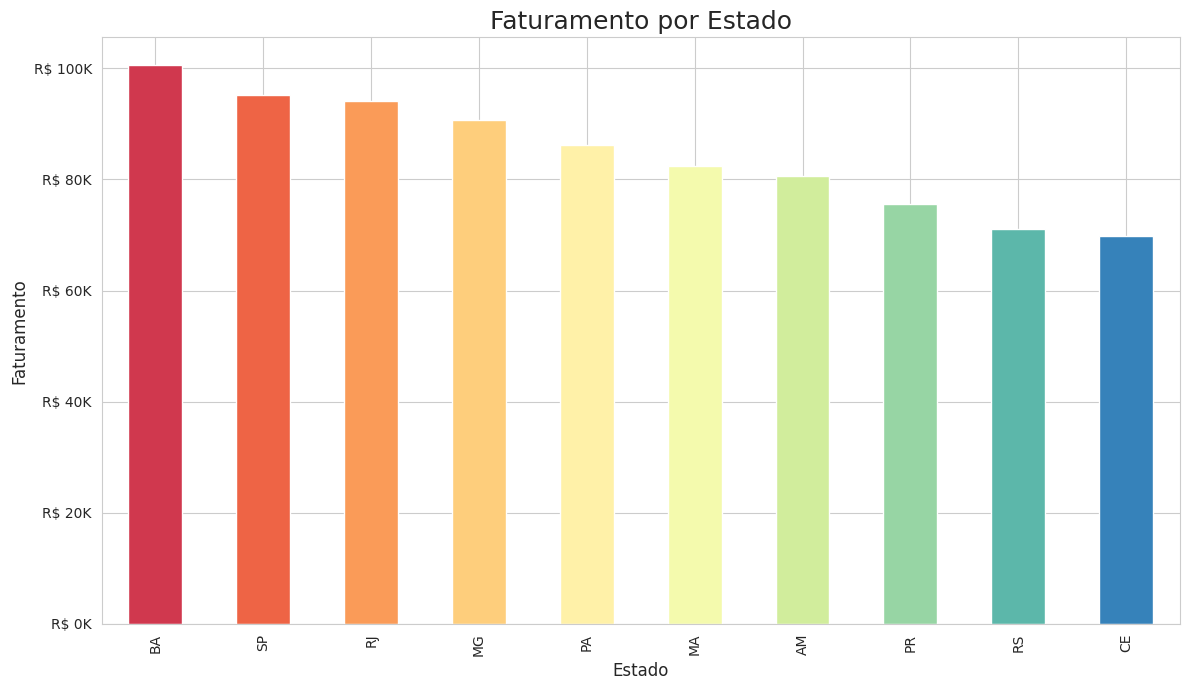

[o resultado completo pode ser consultado em anexo na pasta de arquivos onde está esse código]